# NOTEBOOK THERMIQUE — Grille 8×5×3





- Grille adaptée : 5 colonnes (A–E) × 8 rangées (1–8) × 3 hauteurs
- Parser de position robuste avec regex
- Gestion des lignes mal alignées dans le CSV
- Suppression des valeurs physiquement impossibles avant clipping
- Features CVC: distances aux bouches de chauffage et climatisation
- 120 capteurs utilisés
- Fallback automatique si format Row non reconnu

## ÉTAPE 0 : Installation

In [23]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn plotly scipy
print(' Librairies installées!')

 Librairies installées!


### Imports

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings, re, os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print('Imports OK')

Imports OK


### Paramétrage du système

In [25]:
# PARAMÈTRES DE LA GRILLE
LARGEUR  = 8   # axe X : A–H  (0–7)
LONGUEUR = 5   # axe Y : 0–4
HAUTEUR  = 3   # niveaux H1–H3  (axe Z : 0–2)
N_CAPTEURS = 120  # nombre de capteurs à utiliser

# Limites physiques des températures (capteurs HS en dehors)
T_MIN_PHYSIQUE = -50
T_MAX_PHYSIQUE = 200

# Espacement vertical entre niveaux (mètres)
ESPACEMENT_Z = 0.5

# POSITIONS DES ÉQUIPEMENTS CVC (à ajuster selon votre plan)
# Format : (x, y) dans la grille  — x=0..7 (A–H), y=0..4
# MODIFIEZ CES VALEURS selon votre document Thermo-couple_distribution !
SOURCES_FROID = [   # Bouches de climatisation
    (0, 0),          # Coin A0 — exemple
    (7, 4),          # Coin H4 — exemple
]
SOURCES_CHAUD = [   # Bouches de chauffage
    (3, 2),          # Centre — exemple
    (4, 2),          # Centre — exemple
]

print(f' Grille configurée : {LARGEUR} × {LONGUEUR} × {HAUTEUR}')
print(f'   Capteurs utilisés : {N_CAPTEURS}')
print(f'   Limites physiques : {T_MIN_PHYSIQUE}°C … {T_MAX_PHYSIQUE}°C')
print(f'   Sources froid (clim) : {SOURCES_FROID}')
print(f'   Sources chaud        : {SOURCES_CHAUD}')

 Grille configurée : 8 × 5 × 3
   Capteurs utilisés : 120
   Limites physiques : -50°C … 200°C
   Sources froid (clim) : [(0, 0), (7, 4)]
   Sources chaud        : [(3, 2), (4, 2)]


---
# ÉTAPE 1 : UPLOAD & CHARGEMENT

In [26]:
from google.colab import files

print('Sélectionnez votre fichier CSV...')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f'Fichier : {filename}')

Sélectionnez votre fichier CSV...


Saving ThermoCouple.csv to ThermoCouple.csv
Fichier : ThermoCouple.csv


In [27]:
#  LECTURE ROBUSTE DU CSVStories
# Essayer les 4 combinaisons sep/decimal les plus courantes
df_raw = None
for sep, dec in [(',', ','), (';', '.'), (',', '.'), (';', ',')]:
    try:
        tmp = pd.read_csv(filename, sep=sep, decimal=dec, dtype=str)
        if tmp.shape[1] > 10:
            df_raw = tmp
            print(f' CSV lu  sep="{sep}"  decimal="{dec}"')
            break
    except Exception:
        pass

if df_raw is None:
    raise ValueError(' Impossible de lire le CSV — vérifiez le format.')

# ignorer la 1ère ligne si elle est corrompue
# La 1ère ligne de certains exports contient un timestamp en col 0
# et des valeurs de température en col 1 (décalage d'une colonne)
row0 = str(df_raw.iloc[0, 0])
if re.match(r'^\d+:\d+', row0) or re.match(r'^\d{2}:\d{2}\.\d+', row0):
    print(f'  Ligne 0 corrompue détectée (valeur={row0!r}) → ignorée')
    df_raw = df_raw.iloc[1:].reset_index(drop=True)

print(f'Shape brut : {df_raw.shape}')
print(f'Colonnes (6 premières) : {list(df_raw.columns[:6])}')
print('\n3 premières lignes (colonnes 0–5) :')
print(df_raw.iloc[:3, :6].to_string())

 CSV lu  sep=","  decimal=","
Shape brut : (898, 122)
Colonnes (6 premières) : ['Row', 'Time', 'Temperature1(Temperature:Thermocouple)', 'Temperature2(Temperature:Thermocouple)', 'Temperature3(Temperature:Thermocouple)', 'Temperature4(Temperature:Thermocouple)']

3 premières lignes (colonnes 0–5) :
       Row        Time Temperature1(Temperature:Thermocouple) Temperature2(Temperature:Thermocouple) Temperature3(Temperature:Thermocouple) Temperature4(Temperature:Thermocouple)
0  :59.296     29.8556                                30.1466                                30.2527                                30.3506                                30.5541
1        2  7:53:19 AM                                29.8547                                30.1901                                30.2703                                30.3793
2        3  7:53:39 AM                                29.8754                                30.2145                                30.3095                        

---
# ÉTAPE 2 : NETTOYAGE

In [28]:
df = df_raw.copy()

# 1. Identifier les colonnes de température
temp_cols_all = [c for c in df.columns
                 if re.match(r'Temperature\d+', c, re.I) or
                    re.match(r'Temp\d+', c, re.I)]
temp_cols = temp_cols_all[:N_CAPTEURS]
print(f' {len(temp_cols_all)} colonnes température → {len(temp_cols)} utilisées')

# 2. Convertir en float (virgule ou point décimal)
for col in temp_cols:
    df[col] = (
        df[col].astype(str)
               .str.replace(',', '.', regex=False)
               .pipe(pd.to_numeric, errors='coerce')
    )

row_col  = df.columns[0]
time_col = df.columns[1]

# 3. Supprimer valeurs physiquement impossibles
n_bad = 0
for col in temp_cols:
    mask = (df[col] < T_MIN_PHYSIQUE) | (df[col] > T_MAX_PHYSIQUE)
    n_bad += mask.sum()
    df.loc[mask, col] = np.nan
print(f' {n_bad} valeurs hors limites physiques neutralisées (NaN)')

# 4. Clipping 1%–99%
for col in temp_cols:
    p1, p99 = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(p1, p99)
print(' Clipping 1%–99% effectué')

# 5. Température moyenne par ligne (pour référence uniquement)
df['temperature_mean'] = df[temp_cols].mean(axis=1, skipna=True)

n_avant = len(df)
df = df.dropna(subset=['temperature_mean'])
print(f' Lignes conservées : {n_avant} → {len(df)}')

# 6. Statistiques individuelles par capteur
sensor_stats = df[temp_cols].describe().T
print(f'\n Variation spatiale (std par capteur) :')
print(f'   Min std : {sensor_stats["std"].min():.3f}°C')
print(f'   Max std : {sensor_stats["std"].max():.3f}°C')
print(f'   Moy std : {sensor_stats["std"].mean():.3f}°C')
print(f'\n Variation spatiale instantanée (std inter-capteurs par ligne) :')
spatial_std = df[temp_cols].std(axis=1)
print(f'   Moy : {spatial_std.mean():.3f}°C  |  Max : {spatial_std.max():.3f}°C')

 120 colonnes température → 120 utilisées
 0 valeurs hors limites physiques neutralisées (NaN)
 Clipping 1%–99% effectué
 Lignes conservées : 898 → 898

 Variation spatiale (std par capteur) :
   Min std : 2.188°C
   Max std : 3.391°C
   Moy std : 3.052°C

 Variation spatiale instantanée (std inter-capteurs par ligne) :
   Moy : 0.761°C  |  Max : 1.048°C


### Visualisations rapides

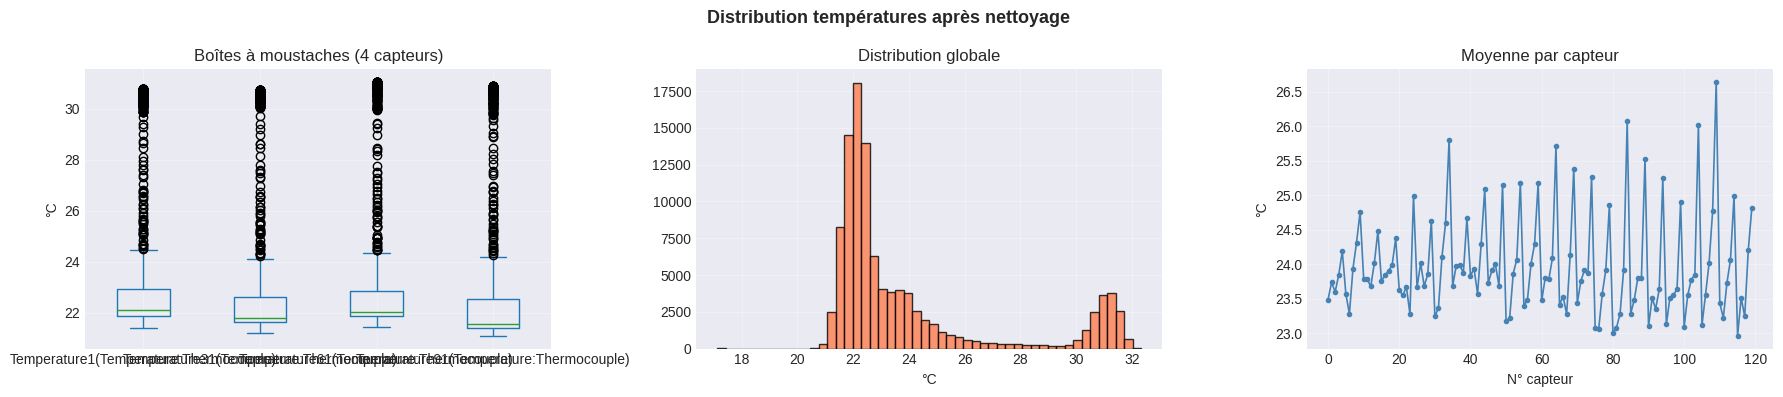

Nettoyage terminé


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Distribution températures après nettoyage', fontsize=13, fontweight='bold')

sample_cols = temp_cols[::max(1, len(temp_cols)//4)][:4]
df[sample_cols].plot(kind='box', ax=axes[0])
axes[0].set_title('Boîtes à moustaches (4 capteurs)')
axes[0].set_ylabel('°C'); axes[0].grid(True, alpha=0.3)

vals = df[temp_cols].values.flatten()
vals = vals[~np.isnan(vals)]
axes[1].hist(vals, bins=50, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title('Distribution globale'); axes[1].set_xlabel('°C'); axes[1].grid(True, alpha=0.3)

axes[2].plot(df[temp_cols].mean().values, 'o-', ms=3, lw=1.2, color='steelblue')
axes[2].set_title('Moyenne par capteur'); axes[2].set_xlabel('N° capteur'); axes[2].set_ylabel('°C'); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print('Nettoyage terminé')

---
# ÉTAPE 3 : PARSING TEMPS & POSITIONS

In [30]:
# PARSING DU TEMPS
print(f'Colonne temps : "{time_col}"')
print(f'   Exemples : {df[time_col].head(3).tolist()}')

time_ok = False
for fmt in ['%I:%M:%S %p', '%H:%M:%S', '%M:%S', '%H:%M:%S.%f', '%H:%M']:
    try:
        parsed = pd.to_datetime(df[time_col].astype(str).str.strip(), format=fmt, errors='coerce')
        if parsed.notna().sum() >= max(1, len(df) * 0.5):
            df = df.copy()
            df['time'] = parsed
            t0 = df['time'].min()
            df['t_sec'] = (df['time'] - t0).dt.total_seconds()
            print(f' Temps parsé (format {fmt}) : {df["t_sec"].min():.0f}s – {df["t_sec"].max():.0f}s')
            time_ok = True
            break
    except Exception:
        pass

if not time_ok:
    print(' Parsing temps échoué → index × 20s utilisé')
    df = df.copy()
    df['t_sec'] = np.arange(len(df)) * 20.0

Colonne temps : "Time"
   Exemples : ['29.8556', '7:53:19 AM', '7:53:39 AM']
 Temps parsé (format %I:%M:%S %p) : 0s – 17920s


In [31]:
#  DÉTECTION DIRECTION ALLER-RETOUR
print('\n Détection direction aller-retour du robot...')

df = df.copy()
if 'Direction' in df.columns or 'direction' in df.columns:
    dir_col = 'Direction' if 'Direction' in df.columns else 'direction'
    df['direction'] = df[dir_col].str.upper()
    print(f' Colonne "{dir_col}" utilisée')
else:
    df['t_diff']   = df['t_sec'].diff()
    df['is_jump']  = df['t_diff'] < 0
    df['cycle_num'] = df['is_jump'].cumsum()
    df['direction'] = df['cycle_num'].apply(lambda x: 'ALLER' if x % 2 == 0 else 'RETOUR')
    print(f' Direction détectée automatiquement — {df["cycle_num"].max() + 1} cycle(s)')

df['direction_encode'] = (df['direction'] == 'RETOUR').astype(int)
print(f'   ALLER:  {(df["direction_encode"]==0).sum()} mesures')
print(f'   RETOUR: {(df["direction_encode"]==1).sum()} mesures')


 Détection direction aller-retour du robot...
 Direction détectée automatiquement — 1 cycle(s)
   ALLER:  898 mesures
   RETOUR: 0 mesures


---
# ÉTAPE 3b :  RECONSTRUCTION EN FORMAT LONG
> Correction majeure : au lieu d'une ligne = un instant (moyenne de 120 capteurs),
> on crée une ligne par capteur par instant.
> Chaque capteur a sa position physique (x, y, z) propre → variation spatiale réelle.

In [32]:
# ── MAPPING CAPTEUR → POSITION (x, y, z)
# Grille 8×5×3 = 120 capteurs
# Capteurs numérotés : d'abord par hauteur (Z), puis par colonne X, puis par rangée Y
# Exemple : capteur 1 = (x=0,y=0,z=0)=A0H1, capteur 2 = (x=0,y=0,z=1)=A0H2, etc.
#
# ADAPTEZ ce mapping selon votre document Thermo-couple_distribution !
# Si votre document donne un ordre différent, modifiez la logique ci-dessous.

def build_sensor_positions(largeur, longueur, hauteur):
    """
    Construit le dictionnaire {numéro_capteur: (x, y, z)}
    Ordre : Z varie en premier (H1→H3), puis X (A→H), puis Y (0→4)
    → capteur 1=(0,0,0), 2=(0,0,1), 3=(0,0,2), 4=(0,1,0), ...
    """
    pos = {}
    n = 1
    for y in range(longueur):       # rangées 0–4
        for x in range(largeur):    # colonnes A–H (0–7)
            for z in range(hauteur): # hauteurs H1–H3 (0–2)
                pos[n] = (x, y, z)
                n += 1
    return pos

capteur_positions = build_sensor_positions(LARGEUR, LONGUEUR, HAUTEUR)
print(f' {len(capteur_positions)} positions capteurs construites')
print('   Exemples :')
for k in [1, 2, 3, 4, LARGEUR*HAUTEUR, len(capteur_positions)]:
    if k in capteur_positions:
        x, y, z = capteur_positions[k]
        label = f'{chr(ord("A")+x)}{y}H{z+1}'
        print(f'   Capteur {k:3d} → {label} (x={x}, y={y}, z={z})')

 120 positions capteurs construites
   Exemples :
   Capteur   1 → A0H1 (x=0, y=0, z=0)
   Capteur   2 → A0H2 (x=0, y=0, z=1)
   Capteur   3 → A0H3 (x=0, y=0, z=2)
   Capteur   4 → B0H1 (x=1, y=0, z=0)
   Capteur  24 → H0H3 (x=7, y=0, z=2)
   Capteur 120 → H4H3 (x=7, y=4, z=2)


In [33]:
# CONSTRUCTION DU DATAFRAME LONG
# 1 ligne = 1 capteur × 1 instant  →  N_lignes_CSV × N_CAPTEURS lignes au total

print(' Construction du format long...')
records = []

for _, row in df.iterrows():
    t_val        = float(row['t_sec'])
    dir_val      = int(row['direction_encode'])

    for i, col in enumerate(temp_cols):
        sensor_num = i + 1           # numérotation 1-based
        temp_val   = row[col]        # température individuelle du capteur

        if pd.isna(temp_val):
            continue                 # ignorer les NaN

        pos = capteur_positions.get(sensor_num)
        if pos is None:
            continue

        x, y, z = pos
        records.append({
            'sensor_id':        sensor_num,
            'x':                x,
            'y':                y,
            'z':                z,
            't_sec':            t_val,
            'direction_encode': dir_val,
            'temperature':      float(temp_val),  # ← température INDIVIDUELLE
        })

df_long = pd.DataFrame(records)
print(f' Format long créé : {len(df_long):,} lignes  ({len(df)} instants × {len(temp_cols)} capteurs)')
print(f'\n Statistiques température individuelle :')
print(f'   Min : {df_long["temperature"].min():.2f}°C')
print(f'   Max : {df_long["temperature"].max():.2f}°C')
print(f'   Moy : {df_long["temperature"].mean():.2f}°C')
print(f'   Std : {df_long["temperature"].std():.2f}°C  ← variation réelle !')

 Construction du format long...
 Format long créé : 107,760 lignes  (898 instants × 120 capteurs)

 Statistiques température individuelle :
   Min : 17.13°C
   Max : 32.32°C
   Moy : 23.97°C
   Std : 3.14°C  ← variation réelle !


---
# ÉTAPE 4 : FEATURES — Distances spatiales + CVC
> Ajout des distances aux équipements de chauffage/climatisation.
> Ces features permettent au modèle de capturer l'influence thermique des bouches CVC.

 Features créées :
   dist_edge_x         : 0.00 – 3.00
   dist_edge_y         : 0.00 – 2.00
   dist_edge_z         : 0.00 – 0.50
   dist_center         : 0.50 – 4.06
   dist_froid          : 0.00 – 4.47
   dist_chaud          : 0.00 – 3.61
   influence_froid     : 0.18 – 1.00
   influence_chaud     : 0.22 – 1.00


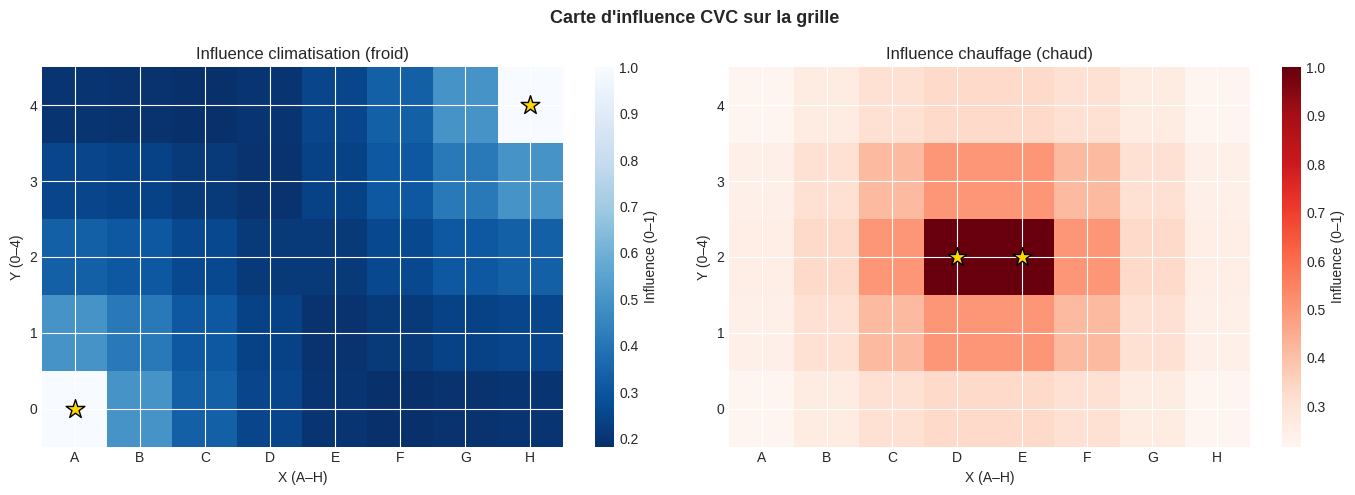

 Carte CVC générée


In [34]:
def dist_min_cvc(x, y, sources):
    """Distance euclidienne minimale vers le groupe de sources le plus proche."""
    if not sources:
        return 99.0
    return min(np.sqrt((x - sx)**2 + (y - sy)**2) for sx, sy in sources)

cx = (LARGEUR  - 1) / 2
cy = (LONGUEUR - 1) / 2
cz = (HAUTEUR  - 1) / 2 * ESPACEMENT_Z

df_long = df_long.copy()

# Features géométriques
df_long['dist_edge_x']  = np.minimum(df_long['x'], (LARGEUR  - 1) - df_long['x'])
df_long['dist_edge_y']  = np.minimum(df_long['y'], (LONGUEUR - 1) - df_long['y'])
df_long['dist_edge_z']  = np.minimum(
    df_long['z'] * ESPACEMENT_Z,
    (HAUTEUR - 1) * ESPACEMENT_Z - df_long['z'] * ESPACEMENT_Z
)
df_long['dist_center']  = np.sqrt(
    (df_long['x'] - cx)**2 +
    (df_long['y'] - cy)**2 +
    (df_long['z'] * ESPACEMENT_Z - cz)**2
)

# ── Features CVC ────────────────────────────────────────────────────────
df_long['dist_froid'] = df_long.apply(
    lambda r: dist_min_cvc(r['x'], r['y'], SOURCES_FROID), axis=1
)
df_long['dist_chaud'] = df_long.apply(
    lambda r: dist_min_cvc(r['x'], r['y'], SOURCES_CHAUD), axis=1
)

# Score d'influence CVC (plus proche = plus influencé)
df_long['influence_froid'] = 1.0 / (1.0 + df_long['dist_froid'])
df_long['influence_chaud'] = 1.0 / (1.0 + df_long['dist_chaud'])

print(' Features créées :')
for col in ['dist_edge_x','dist_edge_y','dist_edge_z','dist_center',
            'dist_froid','dist_chaud','influence_froid','influence_chaud']:
    print(f'   {col:20s}: {df_long[col].min():.2f} – {df_long[col].max():.2f}')

# Visualiser l'influence CVC sur la grille 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sources, title, cmap in zip(
    axes,
    [SOURCES_FROID, SOURCES_CHAUD],
    ['Influence climatisation (froid)', 'Influence chauffage (chaud)'],
    ['Blues_r', 'Reds']
):
    grid_inf = np.zeros((LARGEUR, LONGUEUR))
    for xi in range(LARGEUR):
        for yi in range(LONGUEUR):
            grid_inf[xi, yi] = 1.0 / (1.0 + dist_min_cvc(xi, yi, sources))
    im = ax.imshow(grid_inf.T, origin='lower', cmap=cmap, aspect='auto')
    ax.set_xticks(range(LARGEUR))
    ax.set_xticklabels([chr(ord('A')+i) for i in range(LARGEUR)])
    ax.set_yticks(range(LONGUEUR))
    ax.set_yticklabels(range(LONGUEUR))
    ax.set_xlabel('X (A–H)'); ax.set_ylabel('Y (0–4)')
    ax.set_title(title)
    for sx, sy in sources:
        ax.scatter(sx, sy, s=200, marker='*', c='gold', edgecolors='black', zorder=5)
    plt.colorbar(im, ax=ax, label='Influence (0–1)')

plt.suptitle('Carte d\'influence CVC sur la grille', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(' Carte CVC générée')

---
# ÉTAPE 5 : NORMALISATION

In [35]:
feature_cols = [
    'x', 'y', 'z', 't_sec',
    'dist_edge_x', 'dist_edge_y', 'dist_edge_z', 'dist_center',
    'direction_encode',
    'dist_froid', 'dist_chaud',
    'influence_froid', 'influence_chaud'
]
target_col = 'temperature'
if len(df_long) == 0:
    raise ValueError(' Dataset vide!')

X = df_long[feature_cols].values
y = df_long[target_col].values

print(f' Shape : X={X.shape}, y={y.shape}')
print(f'   Variation cible : {y.std():.3f}°C  (std — doit être > 0.5°C)')

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

print('\n Normalisation OK')
print(f'   Moyennes : {X_scaled.mean(axis=0).round(3)}')
print(f'   Std      : {X_scaled.std(axis=0).round(3)}')

 Shape : X=(107760, 13), y=(107760,)
   Variation cible : 3.141°C  (std — doit être > 0.5°C)

 Normalisation OK
   Moyennes : [-0.  0.  0. nan -0. -0.  0.  0.  0.  0.  0.  0.  0.]
   Std      : [ 1.  1.  1. nan  1.  1.  1.  1.  0.  1.  1.  1.  1.]


---
# ÉTAPE 6 : MODÈLE XGBOOST

In [36]:
test_sz = 0.2 if len(X_scaled) >= 20 else max(0.1, 1/len(X_scaled))
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=test_sz, random_state=42
)
print(f'Train : {len(X_train):,} | Test : {len(X_test):,}')

model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    verbosity=0
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print(' Entraînement terminé!')

Train : 86,208 | Test : 21,552
 Entraînement terminé!



TRAIN — RMSE: 0.2771°C | R²: 0.9922
TEST  — RMSE: 0.2745°C | MAE: 0.1989°C | R²: 0.9925
 Excellent! RMSE < 0.5°C


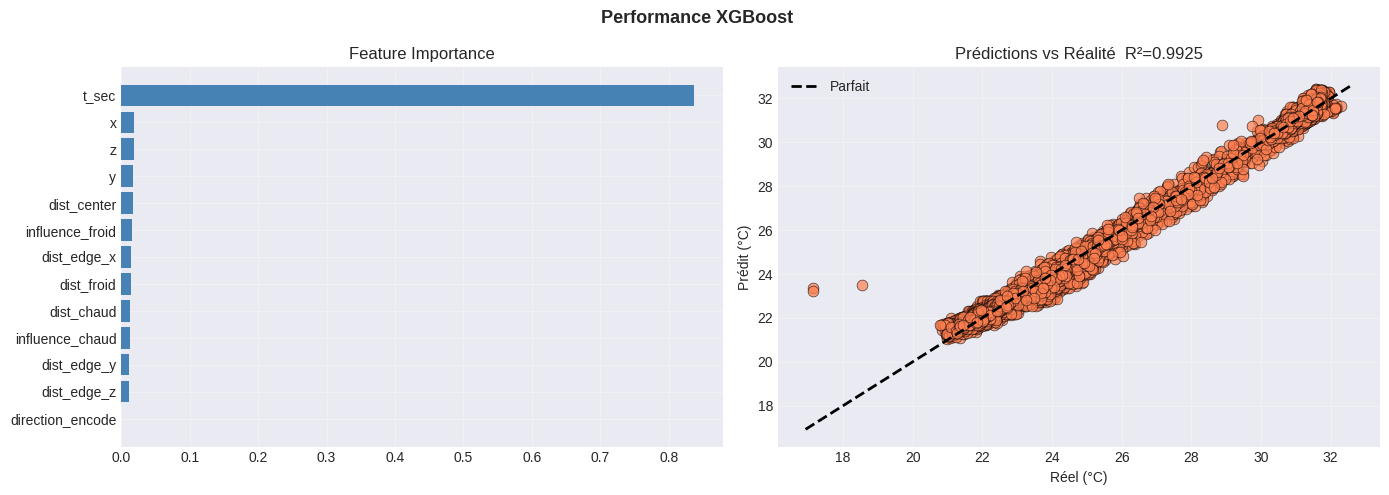

 Graphiques générés


In [37]:
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred))
train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test,  y_test_pred)
test_mae   = mean_absolute_error(y_test, y_test_pred)

print(f'\n{"="*50}')
print(f'TRAIN — RMSE: {train_rmse:.4f}°C | R²: {train_r2:.4f}')
print(f'TEST  — RMSE: {test_rmse:.4f}°C | MAE: {test_mae:.4f}°C | R²: {test_r2:.4f}')
print(f'{"="*50}')
if   test_rmse < 0.5: print(' Excellent! RMSE < 0.5°C')
elif test_rmse < 1.0: print('Bon!       RMSE < 1.0°C')
else:                  print('  À améliorer. RMSE > 1.0°C')

importances   = model.feature_importances_
importance_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})\
                  .sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(' Performance XGBoost', fontsize=13, fontweight='bold')

axes[0].barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
axes[0].set_title('Feature Importance'); axes[0].invert_yaxis(); axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_test_pred, alpha=0.7, s=60, color='coral', edgecolors='black', lw=0.5)
lim = [min(y_test.min(), y_test_pred.min()) - 0.2,
       max(y_test.max(), y_test_pred.max()) + 0.2]
axes[1].plot(lim, lim, 'k--', lw=2, label='Parfait')
axes[1].set_xlabel('Réel (°C)'); axes[1].set_ylabel('Prédit (°C)')
axes[1].set_title(f'Prédictions vs Réalité  R²={test_r2:.4f}')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(' Graphiques générés')

---
# ÉTAPE 7 : INTERPOLATION 3D (grille 8×5×3)

In [38]:
# ÉTAPE 7 : INTERPOLATION 3D — données réelles (sans modèle)

from scipy.interpolate import griddata

RES_X = 32
RES_Y = 20
RES_Z = HAUTEUR

x_grid = np.linspace(0, LARGEUR  - 1, RES_X)
y_grid = np.linspace(0, LONGUEUR - 1, RES_Y)
z_grid = np.arange(HAUTEUR, dtype=float)

X_mesh, Y_mesh, Z_mesh = np.meshgrid(x_grid, y_grid, z_grid, indexing='ij')

# Moyenne réelle par position (x, y, z) — pas de modèle
df_mean = df_long.groupby(['x', 'y', 'z'])['temperature'].mean().reset_index()

print(f'Points mesurés uniques : {len(df_mean)}')
print(f'Variation spatiale réelle :')
print(f'   Min : {df_mean["temperature"].min():.2f}°C')
print(f'   Max : {df_mean["temperature"].max():.2f}°C')
print(f'   Std : {df_mean["temperature"].std():.3f}°C')

# Interpolation spatiale par hauteur avec griddata
T_grid = np.zeros((RES_X, RES_Y, RES_Z))

for h in range(HAUTEUR):
    df_h = df_mean[df_mean['z'] == h]

    # Interpolation sur la grille fine
    T_h = griddata(
        points=(df_h['x'].values, df_h['y'].values),
        values=df_h['temperature'].values,
        xi=(X_mesh[:, :, h], Y_mesh[:, :, h]),
        method='cubic'
    )

    # Fallback nearest pour les zones sans données (NaN)
    nan_mask = np.isnan(T_h)
    if nan_mask.any():
        T_h_near = griddata(
            points=(df_h['x'].values, df_h['y'].values),
            values=df_h['temperature'].values,
            xi=(X_mesh[:, :, h], Y_mesh[:, :, h]),
            method='nearest'
        )
        T_h[nan_mask] = T_h_near[nan_mask]

    T_grid[:, :, h] = T_h
    print(f'   Hauteur {h+1} : {T_h.min():.2f}–{T_h.max():.2f}°C  std={T_h.std():.3f}°C')

y_grid_pred = T_grid.ravel()  # ← gardé pour compatibilité Étape 10

Tmin = np.percentile(y_grid_pred, 2)
Tmax = np.percentile(y_grid_pred, 98)

print(f'\n Interpolation réelle terminée — échelle {Tmin:.2f}°C → {Tmax:.2f}°C')

Points mesurés uniques : 120
Variation spatiale réelle :
   Min : 22.96°C
   Max : 26.64°C
   Std : 0.723°C
   Hauteur 1 : 22.92–26.13°C  std=0.570°C
   Hauteur 2 : 22.82–26.64°C  std=0.624°C
   Hauteur 3 : 22.89–26.02°C  std=0.516°C

 Interpolation réelle terminée — échelle 23.04°C → 25.41°C


---
# ÉTAPE 8 : VISUALISATIONS COMPLÈTES

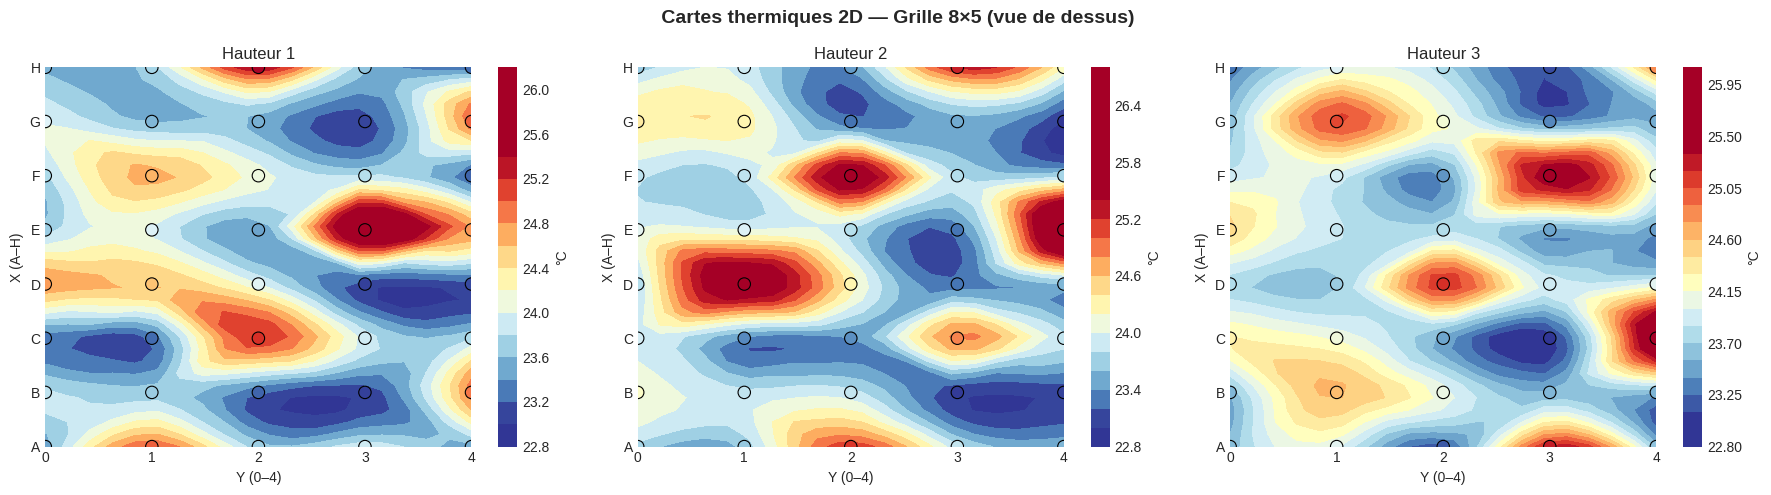

 Heatmaps 2D générées


In [39]:
#  Heatmaps 2D — une par hauteur
fig, axes = plt.subplots(1, HAUTEUR, figsize=(6 * HAUTEUR, 5))
if HAUTEUR == 1:
    axes = [axes]
fig.suptitle(f' Cartes thermiques 2D — Grille {LARGEUR}×{LONGUEUR} (vue de dessus)',
             fontsize=14, fontweight='bold')

col_labels = [chr(ord('A') + i) for i in range(LARGEUR)]    # A B C D E F G H  (axe X)
row_labels  = [str(i) for i in range(LONGUEUR)]               # 0 1 2 3 4          (axe Y)

for h in range(HAUTEUR):
    ax  = axes[h]
    T_h = T_grid[:, :, h]   # shape (RES_X, RES_Y)

    # Heatmap interpolée
    im = ax.contourf(y_grid, x_grid, T_h, levels=20,
                     cmap='RdYlBu_r', vmin=Tmin, vmax=Tmax)

    # Points mesurés à ce niveau (moyenne par position)
    mask = df_long['z'] == h
    if mask.sum() > 0:
        pts = df_long[mask].groupby(['x','y'])['temperature'].mean().reset_index()
        ax.scatter(pts['y'], pts['x'],
                   c=pts['temperature'],
                   s=80, cmap='RdYlBu_r', edgecolors='black', lw=0.8,
                   vmin=Tmin, vmax=Tmax, zorder=5)

    ax.set_xlabel('Y (0–4)')
    ax.set_ylabel('X (A–H)')
    ax.set_title(f'Hauteur {h+1}')
    ax.set_yticks(range(LARGEUR));   ax.set_yticklabels(col_labels)
    ax.set_xticks(range(LONGUEUR));  ax.set_xticklabels(row_labels)
    plt.colorbar(im, ax=ax, label='°C')

plt.tight_layout(); plt.show()
print(' Heatmaps 2D générées')

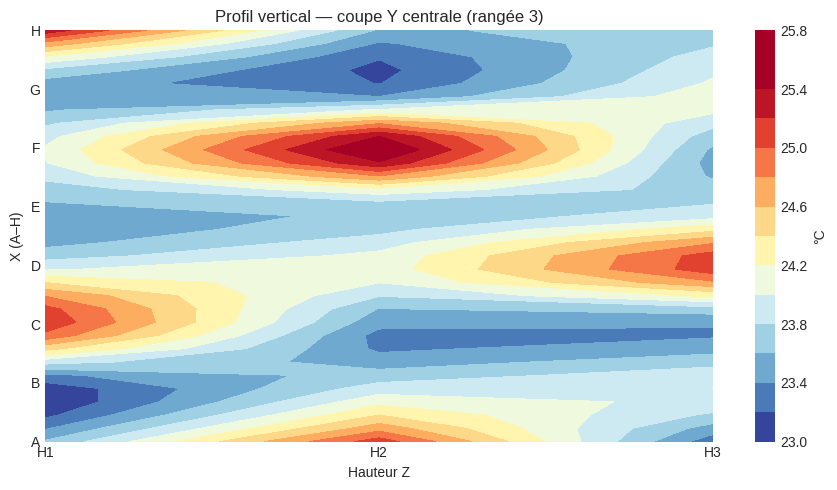

Profil vertical généré


In [40]:


# Profil vertical (coupe centrale Y)
y_center_idx = np.argmin(np.abs(y_grid - (LONGUEUR - 1) / 2))
T_profil = T_grid[:, y_center_idx, :]   # (RES_X, HAUTEUR)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.contourf(z_grid, x_grid, T_profil, levels=15,
                 cmap='RdYlBu_r', vmin=Tmin, vmax=Tmax)
ax.set_xlabel('Hauteur Z'); ax.set_ylabel('X (A–H)')
ax.set_title(f'Profil vertical — coupe Y centrale (rangée {LONGUEUR//2 + 1})')
ax.set_yticks(range(LARGEUR));  ax.set_yticklabels(col_labels)  # A–H
ax.set_xticks(range(HAUTEUR));  ax.set_xticklabels([f'H{i+1}' for i in range(HAUTEUR)])
plt.colorbar(im, ax=ax, label='°C')
plt.tight_layout(); plt.show()
print('Profil vertical généré')


###  Nuage 3D interactif Plotly



In [41]:
# utiliser df_long (température individuelle)
# Agrégation : moyenne par position (x,y,z) pour la visualisation
df_viz = df_long.groupby(['x','y','z'])['temperature'].mean().reset_index()
df_viz.columns = ['x', 'y', 'z', 'temperature']

print(f'Points 3D à afficher : {len(df_viz)}')
print(f'Plage de températures : {df_viz["temperature"].min():.2f}°C → {df_viz["temperature"].max():.2f}°C')
print(f'Std des températures  : {df_viz["temperature"].std():.3f}°C  ← variation visible !')

# ── CORRECTION BUG col_labels_full : cast int + clip sécurisé ────────────
x_clipped = df_viz['x'].astype(int).clip(0, LARGEUR - 1)
col_labels_full = [chr(ord('A') + int(xi)) for xi in x_clipped]

# Labels axes
col_labels = [chr(ord('A') + i) for i in range(LARGEUR)]
row_labels  = [str(i) for i in range(LONGUEUR)]

# Hover text
hover_text = [
    f'{col_labels_full[i]}{int(df_viz["y"].iloc[i])} — H{int(df_viz["z"].iloc[i])+1}'
    f'<br>T={df_viz["temperature"].iloc[i]:.2f}°C'
    for i in range(len(df_viz))
]

# ── Scatter 3D principal ─────────────────────────────────────────────────
traces = [go.Scatter3d(
    x=df_viz['x'], y=df_viz['y'], z=df_viz['z'],
    mode='markers',
    name='Capteurs',
    marker=dict(
        size=8,
        color=df_viz['temperature'],
        colorscale='RdYlBu_r',
        showscale=True,
        colorbar=dict(title='°C', thickness=15),
        opacity=0.9,
        cmin=df_viz['temperature'].min(),
        cmax=df_viz['temperature'].max(),
        line=dict(width=0.5, color='white')
    ),
    text=hover_text,
    hovertemplate='%{text}<extra></extra>'
)]

# ── Marqueurs CVC dans la scène 3D ──────────────────────────────────────
for (sx, sy), label, color in [
    *[(s, 'Clim', 'blue') for s in SOURCES_FROID],
    *[(s, 'Chauf', 'red')  for s in SOURCES_CHAUD]
]:
    traces.append(go.Scatter3d(
        x=[sx], y=[sy], z=[-0.3],
        mode='markers+text',
        name=f'{label} ({sx},{sy})',
        text=[label],
        textposition='top center',
        marker=dict(size=12, color=color, symbol='diamond', opacity=0.8)
    ))

fig3d = go.Figure(data=traces)
fig3d.update_layout(
    title=f'🌡️ Carte thermique 3D — Grille {LARGEUR}×{LONGUEUR}×{HAUTEUR} (températures individuelles)',
    scene=dict(
        xaxis=dict(title='X (A–H)', tickvals=list(range(LARGEUR)), ticktext=col_labels),
        yaxis=dict(title='Y (0–4)', tickvals=list(range(LONGUEUR)), ticktext=row_labels),
        zaxis=dict(title='Hauteur', tickvals=list(range(HAUTEUR)),
                   ticktext=[f'H{i+1}' for i in range(HAUTEUR)]),
        camera=dict(eye=dict(x=-1.6, y=-1.6, z=1.2))
    ),
    width=950, height=680,
    legend=dict(x=0.01, y=0.99)
)
fig3d.show()
print(' Visualisation 3D interactive générée — avec variation thermique réelle!')

Points 3D à afficher : 120
Plage de températures : 22.96°C → 26.64°C
Std des températures  : 0.723°C  ← variation visible !


 Visualisation 3D interactive générée — avec variation thermique réelle!


In [42]:
# ── Zones extrêmes ──────────────────────────────────────────────────────
wi = df_viz['temperature'].idxmax()
ci = df_viz['temperature'].idxmin()
wx, wy, wz = int(df_viz.loc[wi,'x']), int(df_viz.loc[wi,'y']), int(df_viz.loc[wi,'z'])
cxi, cy2, cz2 = int(df_viz.loc[ci,'x']), int(df_viz.loc[ci,'y']), int(df_viz.loc[ci,'z'])

print(f'\n Zone la plus chaude : {chr(ord("A")+wx)}{wy}H{wz+1} → {df_viz.loc[wi,"temperature"]:.2f}°C')
print(f' Zone la plus froide : {chr(ord("A")+cxi)}{cy2}H{cz2+1} → {df_viz.loc[ci,"temperature"]:.2f}°C')
print(f' Gradient thermique  : {df_viz.loc[wi,"temperature"] - df_viz.loc[ci,"temperature"]:.2f}°C')


 Zone la plus chaude : E4H2 → 26.64°C
 Zone la plus froide : G4H2 → 22.96°C
 Gradient thermique  : 3.68°C


---
# ÉTAPE 9 : TRAJECTOIRE SERPENTIN DU ROBOT

Positions XY uniques : 40
Capteurs par position : [5, 5, 5, 5, 5] ...

Trajectoire serpentin 2D :
  Positions par tour : 40
  Total (2 tours)    : 80


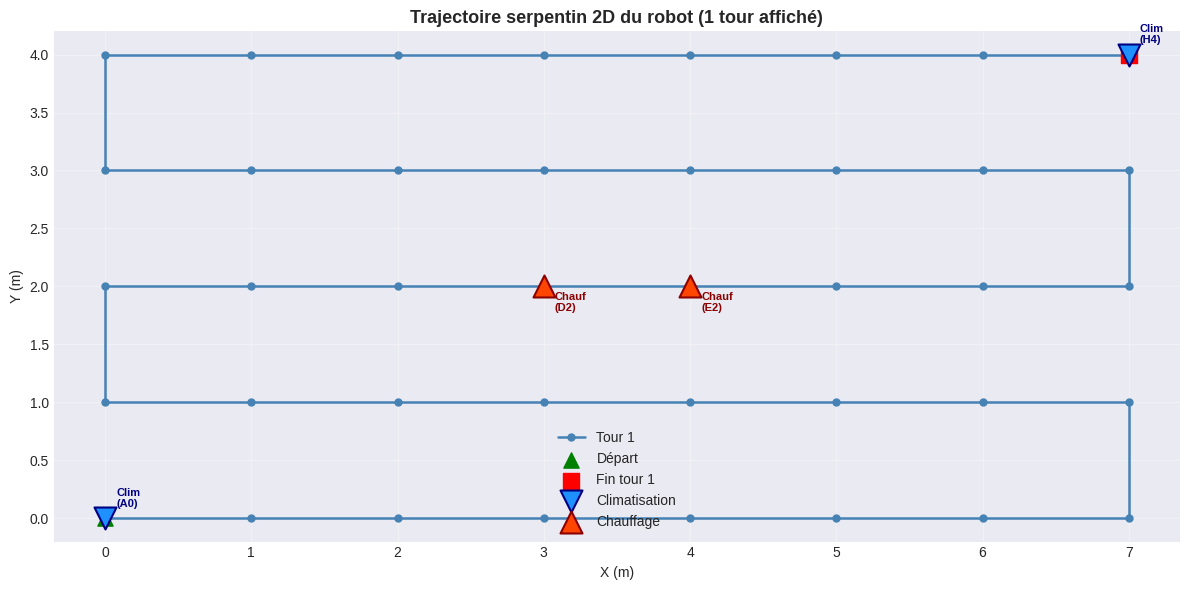

In [43]:
# TRAJECTOIRE SERPENTIN 2D DU ROBOT
N_TOURS   = 2
ECHELLE_X = 1.0
ECHELLE_Y = 1.0

# df_long contient les colonnes x, y issues du format long
x_unique = sorted(df_long['x'].unique())
y_unique = sorted(df_long['y'].unique())

def build_serpentin(x_pos, y_pos, sx, sy, n_tours):
    xs_m = [x * sx for x in x_pos]
    ys_m = [y * sy for y in y_pos]
    tours = []
    for _ in range(n_tours):
        coords = []
        for j, y_m in enumerate(ys_m):
            row_xs = xs_m if j % 2 == 0 else xs_m[::-1]
            for x_m in row_xs:
                coords.append((x_m, y_m))
        tours.append(coords)
    return tours

trajectoire = build_serpentin(x_unique, y_unique, ECHELLE_X, ECHELLE_Y, N_TOURS)

print(f'Positions XY uniques : {len(x_unique) * len(y_unique)}')
print(f'Capteurs par position : {[len(y_unique)] * min(5, len(x_unique))} ...')
print(f'\nTrajectoire serpentin 2D :')
print(f'  Positions par tour : {len(trajectoire[0])}')
print(f'  Total ({N_TOURS} tours)    : {sum(len(t) for t in trajectoire)}')

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title('Trajectoire serpentin 2D du robot (1 tour affiché)', fontsize=13, fontweight='bold')

traj = trajectoire[0]
xs_t = [p[0] for p in traj]
ys_t = [p[1] for p in traj]
ax.plot(xs_t, ys_t, 'o-', color='steelblue', linewidth=1.8, markersize=5, label='Tour 1')
ax.scatter(xs_t[0],  ys_t[0],  s=120, marker='^', color='green', zorder=5, label='Départ')
ax.scatter(xs_t[-1], ys_t[-1], s=120, marker='s', color='red',   zorder=5, label='Fin tour 1')

#  Affichage équipements CVC
for i, (sx, sy) in enumerate(SOURCES_FROID):
    ax.scatter(sx * ECHELLE_X, sy * ECHELLE_Y,
               s=250, marker='v', color='dodgerblue', edgecolors='navy',
               linewidths=1.5, zorder=6,
               label='Climatisation' if i == 0 else '')
    ax.annotate(f'Clim\n({chr(ord("A")+sx)}{sy})',
                xy=(sx * ECHELLE_X, sy * ECHELLE_Y),
                xytext=(8, 8), textcoords='offset points',
                fontsize=8, color='navy', fontweight='bold')

for i, (sx, sy) in enumerate(SOURCES_CHAUD):
    ax.scatter(sx * ECHELLE_X, sy * ECHELLE_Y,
               s=250, marker='^', color='orangered', edgecolors='darkred',
               linewidths=1.5, zorder=6,
               label='Chauffage' if i == 0 else '')
    ax.annotate(f'Chauf\n({chr(ord("A")+sx)}{sy})',
                xy=(sx * ECHELLE_X, sy * ECHELLE_Y),
                xytext=(8, -18), textcoords='offset points',
                fontsize=8, color='darkred', fontweight='bold')

ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.legend(loc='lower center'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
# ÉTAPE 10 : EXPORT & TÉLÉCHARGEMENT


In [44]:
# Étape 10 : EXPORT & TÉLÉCHARGEMENT

import pandas as pd

# ─── CORRECTION : reconstruire gd depuis les meshgrids ───────────────────────
gd = pd.DataFrame({
    'x': X_mesh.ravel(),
    'y': Y_mesh.ravel(),
    'z': Z_mesh.ravel(),
})
# ─────────────────────────────────────────────────────────────────────────────

# Grille interpolée
grid_out = gd[['x', 'y', 'z']].copy()
grid_out['x_label'] = grid_out['x'].apply(
    lambda v: chr(ord('A') + round(v)) if 0 <= round(v) < LARGEUR else '?'
)
grid_out['y_label'] = grid_out['y'].round().astype(int)
grid_out['z_label'] = (grid_out['z'] + 1).round().astype(int)
grid_out['temperature_predicted'] = y_grid_pred
grid_out.to_csv('thermal_grid_8x5x3.csv', index=False)
print(f'thermal_grid_8x5x3.csv ({len(grid_out)} points)')

# Résumé
summary = f"""
═══════════════════════════════════════════════════════════
     RÉSUMÉ — PIPELINE THERMIQUE  Grille {LARGEUR}×{LONGUEUR}×{HAUTEUR}
═══════════════════════════════════════════════════════════
Capteurs utilisés  : {len(temp_cols)}
Instants mesurés   : {len(df)}
Lignes format long : {len(df_long):,}
SOURCES CVC :
  Froid (clim)  : {SOURCES_FROID}
  Chaud (chauf) : {SOURCES_CHAUD}
PERFORMANCE XGBoost :
  Train RMSE  : {train_rmse:.4f}°C
  Test  RMSE  : {test_rmse:.4f}°C
  Test  MAE   : {test_mae:.4f}°C
  Test  R²    : {test_r2:.4f}
FEATURE IMPORTANCE (top 5) :
{importance_df.head(5).to_string(index=False)}
ZONES EXTRÊMES (moyennes spatiales) :
  Chaude  : {chr(ord('A')+wx)}{wy}H{wz+1} → {df_viz.loc[wi,'temperature']:.2f}°C
  Froide  : {chr(ord('A')+cxi)}{cy2}H{cz2+1} → {df_viz.loc[ci,'temperature']:.2f}°C
  Gradient: {df_viz.loc[wi,'temperature'] - df_viz.loc[ci,'temperature']:.2f}°C
═══════════════════════════════════════════════════════════
"""
with open('model_summary_8x5x3.txt', 'w') as f:
    f.write(summary)
print(summary)

from google.colab import files
for fname in ['thermal_grid_8x5x3.csv', 'thermal_data_long_8x5x3.csv', 'model_summary_8x5x3.txt']:
    if os.path.exists(fname):
        files.download(fname)
print('\n PIPELINE COMPLET — Grille 8×5×3 avec CVC!')


thermal_grid_8x5x3.csv (1920 points)

═══════════════════════════════════════════════════════════
     RÉSUMÉ — PIPELINE THERMIQUE  Grille 8×5×3
═══════════════════════════════════════════════════════════
Capteurs utilisés  : 120
Instants mesurés   : 898
Lignes format long : 107,760
SOURCES CVC :
  Froid (clim)  : [(0, 0), (7, 4)]
  Chaud (chauf) : [(3, 2), (4, 2)]
PERFORMANCE XGBoost :
  Train RMSE  : 0.2771°C
  Test  RMSE  : 0.2745°C
  Test  MAE   : 0.1989°C
  Test  R²    : 0.9925
FEATURE IMPORTANCE (top 5) :
    Feature  Importance
      t_sec    0.837623
          x    0.018533
          z    0.018524
          y    0.017382
dist_center    0.017328
ZONES EXTRÊMES (moyennes spatiales) :
  Chaude  : E4H2 → 26.64°C
  Froide  : G4H2 → 22.96°C
  Gradient: 3.68°C
═══════════════════════════════════════════════════════════



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 PIPELINE COMPLET — Grille 8×5×3 avec CVC!
